In [2]:
!pip install dpkt

In [4]:
import dpkt
import socket
from collections import defaultdict
import numpy as np
import pandas as pd

def inet_to_str(inet):
    try:
        return socket.inet_ntop(socket.AF_INET, inet)
    except ValueError:
        return socket.inet_ntop(socket.AF_INET6, inet)

def process_pcap_flows(pcap_file, max_flows=1000, packets_per_flow=16):
    flows = defaultdict(lambda: {
        "sizes": [],
        "timestamps": [],
        "syn_flags": [],  # Store SYN flags per packet
        "ack_flags": []   # Store ACK flags per packet
    })
    
    with open(pcap_file, "rb") as f:
        pcap = dpkt.pcap.Reader(f)
        
        for ts, buf in pcap:
            try:
                eth = dpkt.ethernet.Ethernet(buf)
                if not isinstance(eth.data, dpkt.ip.IP):
                    continue
                ip = eth.data
                if not isinstance(ip.data, dpkt.tcp.TCP):
                    continue
                
                tcp = ip.data
                src = inet_to_str(ip.src)
                dst = inet_to_str(ip.dst)
                flow_key = (src, dst, tcp.sport, tcp.dport)
                
                # Skip if we have enough flows
                if len(flows) >= max_flows and flow_key not in flows:
                    continue
                
                # Record packet info for all packets
                flows[flow_key]["sizes"].append(len(buf))
                flows[flow_key]["timestamps"].append(ts)
                flows[flow_key]["syn_flags"].append(1 if tcp.flags & dpkt.tcp.TH_SYN else 0)
                flows[flow_key]["ack_flags"].append(1 if tcp.flags & dpkt.tcp.TH_ACK else 0)
                    
            except Exception:
                continue
    
    # Extract features for each 16-packet window per flow
    features = []
    for flow_key, stats in flows.items():
        sizes = stats["sizes"]
        timestamps = stats["timestamps"]
        syn_flags = stats["syn_flags"]
        ack_flags = stats["ack_flags"]
        
        # Skip flows with insufficient packets
        if len(sizes) < 2:
            continue
            
        # Process in non-overlapping 16-packet windows
        for window_start in range(0, len(sizes), packets_per_flow):
            window_end = window_start + packets_per_flow
            window_sizes = sizes[window_start:window_end]
            window_timestamps = timestamps[window_start:window_end]
            window_syn_flags = syn_flags[window_start:window_end]
            window_ack_flags = ack_flags[window_start:window_end]
            
            # Skip windows with insufficient packets
            if len(window_sizes) < 2:
                continue
                
            # Calculate IAT for this window
            window_iats = np.diff(window_timestamps)
            
            # Count SYN/ACK flags in this window
            window_syn_count = np.sum(window_syn_flags)
            window_ack_count = np.sum(window_ack_flags)
            
            features.append({
                "src_ip": flow_key[0],
                "dst_ip": flow_key[1],
                "src_port": flow_key[2],
                "dst_port": flow_key[3],
                "window_id": window_start // packets_per_flow,
                "pkt_size_min": np.min(window_sizes),
                "pkt_size_max": np.max(window_sizes),
                "pkt_size_mean": np.mean(window_sizes),
                "iat_min": np.min(window_iats),
                "iat_max": np.max(window_iats), 
                "iat_mean": np.mean(window_iats),
                "syn_count": window_syn_count,
                "ack_count": window_ack_count
            })
    
    return pd.DataFrame(features)

In [5]:

df_normal = process_pcap_flows("/home/ubuntu/raw_data/normal/normal_traffic_2025-01-09_22_43_09.pcap")
print(f"Processed {len(df_normal)} flows")
print(df_normal.head())

Processed 178954 flows
         src_ip        dst_ip  src_port  dst_port  window_id  pkt_size_min  \
0  192.168.0.11  192.168.0.12     35610       502          0            66   
1  192.168.0.11  192.168.0.12     35610       502          1            66   
2  192.168.0.11  192.168.0.12     35610       502          2            66   
3  192.168.0.11  192.168.0.12     35610       502          3            66   
4  192.168.0.11  192.168.0.12     35610       502          4            66   

   pkt_size_max  pkt_size_mean   iat_min   iat_max  iat_mean  syn_count  \
0            78          73.50  0.000023  0.163084  0.040074          0   
1            78          72.75  0.000028  0.157807  0.039807          0   
2            78          73.50  0.000022  0.159656  0.040134          0   
3            78          73.50  0.000050  0.180384  0.039867          0   
4            78          72.75  0.000047  0.181712  0.039989          0   

   ack_count  
0         16  
1         16  
2         16

In [6]:
df_attack = process_pcap_flows("/home/ubuntu/raw_data/attack/normal_traffic_2025-02-11_20_27_15.pcap")
print(f"Processed {len(df_attack)} flows")
print(df_attack.head())

Processed 76118 flows
         src_ip        dst_ip  src_port  dst_port  window_id  pkt_size_min  \
0  192.168.0.11  192.168.0.12     42024       502          0            66   
1  192.168.0.11  192.168.0.12     42024       502          1            66   
2  192.168.0.11  192.168.0.12     42024       502          2            66   
3  192.168.0.11  192.168.0.12     42024       502          3            66   
4  192.168.0.11  192.168.0.12     42024       502          4            66   

   pkt_size_max  pkt_size_mean   iat_min   iat_max  iat_mean  syn_count  \
0            78          73.50  0.000023  0.181141  0.040053          0   
1            78          72.75  0.000109  0.190205  0.039946          0   
2            78          73.50  0.000218  0.211367  0.040330          0   
3            78          73.50  0.000070  0.160545  0.039362          0   
4            78          72.75  0.000027  0.161558  0.039983          0   

   ack_count  
0         16  
1         16  
2         16 

In [7]:
print(df_normal.shape, df_attack.shape)


(178954, 13) (76118, 13)


Training Accuracy: 0.9881
Test Accuracy: 0.9881

Classification Report:
              precision    recall  f1-score   support

           0     0.9835    0.9999    0.9916     53686
           1     0.9996    0.9605    0.9797     22836

    accuracy                         0.9881     76522
   macro avg     0.9915    0.9802    0.9856     76522
weighted avg     0.9883    0.9881    0.9880     76522



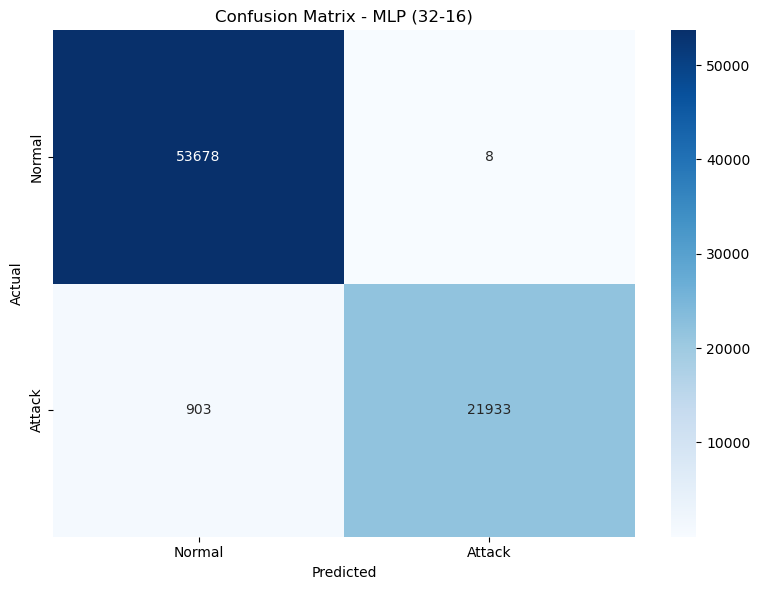

Generated mlp_weights.h and feature_stats.h

Dataset Info:
Normal flows: 178954
Attack flows: 76118
Total flows: 255072


In [21]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def train_mlp_model(df_normal, df_attack):
    """Train MLP classifier with 32-16 architecture using DataFrames"""
    
    # Add labels
    df_normal['label'] = 0  # Normal traffic
    df_attack['label'] = 1  # Attack traffic
    
    # Combine datasets
    df = pd.concat([df_normal, df_attack], ignore_index=True)
    
    # Select the 8 features
    feature_columns = ['pkt_size_min', 'pkt_size_max', 'pkt_size_mean', 
                      'iat_min', 'iat_max', 'iat_mean', 'syn_count', 'ack_count']
    
    X = df[feature_columns]
    y = df['label']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    
    # Normalize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Train MLP with 32-16 architecture
    mlp = MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation='relu',
        solver='adam',
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1
    )
    
    mlp.fit(X_train_scaled, y_train)
    
    # Predictions
    y_pred = mlp.predict(X_test_scaled)
    
    # Evaluate model
    train_score = mlp.score(X_train_scaled, y_train)
    test_score = mlp.score(X_test_scaled, y_test)
    
    print(f"Training Accuracy: {train_score:.4f}")
    print(f"Test Accuracy: {test_score:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    
    # Plot confusion matrix
    plot_confusion_matrix(y_test, y_pred)
    
    return mlp, scaler, X_train, X_test, y_train, y_test, y_pred

def plot_confusion_matrix(y_true, y_pred):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'])
    plt.title('Confusion Matrix - MLP (32-16)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

def generate_c_headers(mlp, scaler):
    """Generate C header files for the trained model"""
    
    # Generate mlp_weights.h
    with open('mlp_weights.h', 'w') as f:
        f.write('#ifndef MLP_WEIGHTS_H\n')
        f.write('#define MLP_WEIGHTS_H\n\n')
        
        f.write('#define NUM_LAYERS 3\n')
        f.write('#define LAYER_SIZES {8, 32, 16, 1}\n\n')
        
        # Weights
        f.write('static const float WEIGHTS[][32 * 16] = {\n')
        for i, coef in enumerate(mlp.coefs_):
            f.write('    {')
            # Flatten weights matrix
            weights_flat = coef.flatten()
            f.write(', '.join([f'{w:.6f}f' for w in weights_flat]))
            f.write('},\n')
        f.write('};\n\n')
        
        # Biases
        f.write('static const float BIASES[][16] = {\n')
        for i, intercept in enumerate(mlp.intercepts_):
            f.write('    {')
            f.write(', '.join([f'{b:.6f}f' for b in intercept]))
            f.write('},\n')
        f.write('};\n\n')
        
        f.write('#endif\n')
    
    # Generate feature_stats.h
    with open('feature_stats.h', 'w') as f:
        f.write('#ifndef FEATURE_STATS_H\n')
        f.write('#define FEATURE_STATS_H\n\n')
        
        f.write('#define NUM_FEATURES 8\n\n')
        
        f.write('static const float FEATURE_MEAN[NUM_FEATURES] = {\n    ')
        f.write(', '.join([f'{m:.6f}f' for m in scaler.mean_]))
        f.write('\n};\n\n')
        
        f.write('static const float FEATURE_STD[NUM_FEATURES] = {\n    ')
        f.write(', '.join([f'{s:.6f}f' for s in scaler.scale_]))
        f.write('\n};\n\n')
        
        f.write('#endif\n')
    
    print("Generated mlp_weights.h and feature_stats.h")

if __name__ == "__main__":
    
    # Train model directly with DataFrames
    mlp, scaler, X_train, X_test, y_train, y_test, y_pred = train_mlp_model(df_normal, df_attack)
    
    # Generate C headers for your DPDK code
    generate_c_headers(mlp, scaler)
    
    # Print dataset info
    print(f"\nDataset Info:")
    print(f"Normal flows: {len(df_normal)}")
    print(f"Attack flows: {len(df_attack)}")
    print(f"Total flows: {len(df_normal) + len(df_attack)}")

/home/ubuntu/miniconda/envs/jupyterenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/home/ubuntu/miniconda/envs/jupyterenv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Creating SHAP KernelExplainer (this may take a moment)...
Computing SHAP values on 5000 samples (this can be slow)...


100%|██████████| 5000/5000 [00:22<00:00, 225.77it/s]



Top 5 features by mean |SHAP| (positive class):
     feature  mean_abs_shap
   ack_count       0.233524
     iat_max       0.145626
pkt_size_max       0.110818
    iat_mean       0.102465
pkt_size_min       0.094066

Saved shap_feature_importance.csv and shap_top5_features.csv


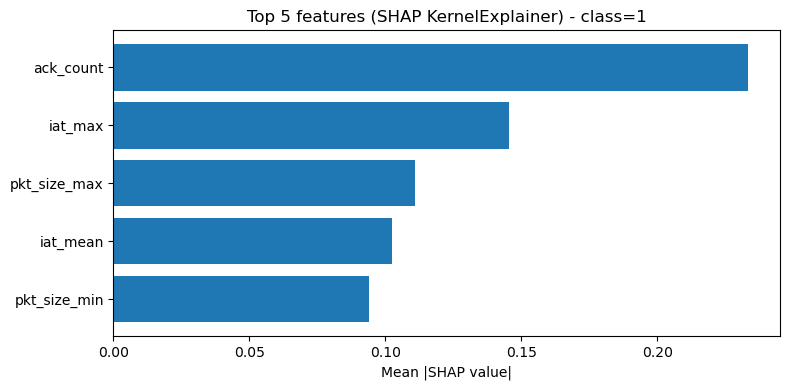

Rendering SHAP summary plot (beeswarm) for explained subset...


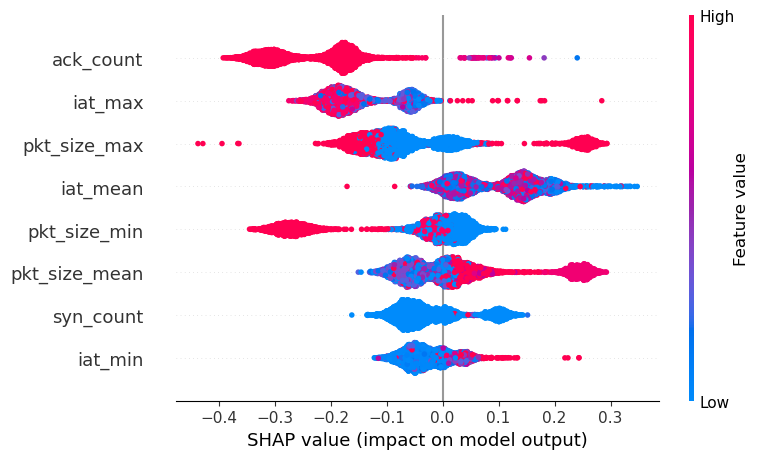

In [9]:
# Jupyter cell: compute SHAP Kernel top-K features and plots
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# Parameters you can tune
TOP_K = 5                    # number of top features to report
BG_KMEANS = 50               # number of background kmeans centers (smaller -> faster)
N_EXPLAIN = 5000              # number of test samples to explain (subset if X_test large)
RANDOM_STATE = 42

# Ensure feature names exist
try:
    feature_names = list(feature_columns)
except NameError:
    # fallback: infer from X_test (if DataFrame)
    if hasattr(X_test, "columns"):
        feature_names = list(X_test.columns)
    else:
        raise RuntimeError("feature_columns not found and X_test has no .columns")

# Prepare data to explain (scaled)
# If X_test is a DataFrame, use values; else assume numpy array
X_test_arr = X_test.values if hasattr(X_test, "values") else np.asarray(X_test)
X_train_arr = X_train.values if hasattr(X_train, "values") else np.asarray(X_train)

# Use the scaler to transform if needed (you already produced X_train_scaled and X_test_scaled earlier).
# Prefer to explain on scaled inputs because model was trained on scaled inputs.
try:
    X_test_scaled = scaler.transform(X_test_arr)
    X_train_scaled = scaler.transform(X_train_arr)
except Exception:
    # if earlier scaled arrays exist, use them
    try:
        X_test_scaled = X_test_scaled
        X_train_scaled = X_train_scaled
    except NameError:
        raise RuntimeError("Cannot obtain scaled features. Ensure `scaler` is defined or X_*_scaled is available.")

# Create a small background dataset for KernelExplainer (k-means or random sample)
rng = np.random.RandomState(RANDOM_STATE)
if BG_KMEANS and BG_KMEANS > 1:
    try:
        background = shap.kmeans(X_train_scaled, BG_KMEANS).data
    except Exception:
        # fallback to random sample if kmeans not available
        idx_bg = rng.choice(X_train_scaled.shape[0], min(BG_KMEANS, X_train_scaled.shape[0]), replace=False)
        background = X_train_scaled[idx_bg]
else:
    idx_bg = rng.choice(X_train_scaled.shape[0], min(50, X_train_scaled.shape[0]), replace=False)
    background = X_train_scaled[idx_bg]

# Select subset of X_test to explain (to keep KernelExplainer time acceptable)
n_explain = min(N_EXPLAIN, X_test_scaled.shape[0])
idx_explain = rng.choice(X_test_scaled.shape[0], n_explain, replace=False)
X_explain = X_test_scaled[idx_explain]

# Model prediction wrapper: KernelExplainer expects a function that maps (nsamples, nfeatures) -> model output.
# We explain the probability of the positive class (class 1).
def model_proba_pos(x):
    # x may be 2D numpy array
    proba = mlp.predict_proba(x)
    # return probability of class 1 (second column)
    return proba[:, 1]

# Create KernelExplainer
print("Creating SHAP KernelExplainer (this may take a moment)...")
explainer = shap.KernelExplainer(model_proba_pos, background, link="identity")

# Compute shap values for positive class (KernelExplainer returns shap values matching model output)
print(f"Computing SHAP values on {n_explain} samples (this can be slow)...")
# Use nsamples argument to speed up (smaller -> faster, but less accurate); set to "auto" or integer
shap_values = explainer.shap_values(X_explain, nsamples=100)

# KernelExplainer returns a single array for scalar-output model; ensure shape consistency
# shap_values shape: (n_explain, n_features)
if isinstance(shap_values, list) and len(shap_values) == 2:
    # sometimes shap returns list for multi-output; choose the second (positive class)
    sv = np.array(shap_values[1])
else:
    sv = np.array(shap_values)

# Compute mean absolute SHAP per feature
mean_abs_shap = np.mean(np.abs(sv), axis=0)
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

# Top-K features
topk = feat_imp.head(TOP_K)
print(f"\nTop {TOP_K} features by mean |SHAP| (positive class):")
print(topk.to_string(index=False))

# Save to CSV
feat_imp.to_csv("shap_feature_importance.csv", index=False)
topk.to_csv("shap_top{}_features.csv".format(TOP_K), index=False)
print("\nSaved shap_feature_importance.csv and shap_top{}_features.csv".format(TOP_K))

# Plot bar chart for top-K
plt.figure(figsize=(8, 4))
plt.barh(topk['feature'][::-1], topk['mean_abs_shap'][::-1])
plt.xlabel("Mean |SHAP value|")
plt.title(f"Top {TOP_K} features (SHAP KernelExplainer) - class=1")
plt.tight_layout()
plt.show()

# SHAP summary plot (beeswarm) for the explained subset (uses original scaled values)
# Convert X_explain back to a DataFrame with feature names for nicer plotting
try:
    X_explain_df = pd.DataFrame(X_explain, columns=feature_names)
    # summary_plot expects a 2D array of shap values with shape (nsamples, nfeatures)
    print("Rendering SHAP summary plot (beeswarm) for explained subset...")
    shap.summary_plot(sv, X_explain_df, feature_names=feature_names, show=True)
except Exception as e:
    print("Could not render SHAP summary plot:", e)


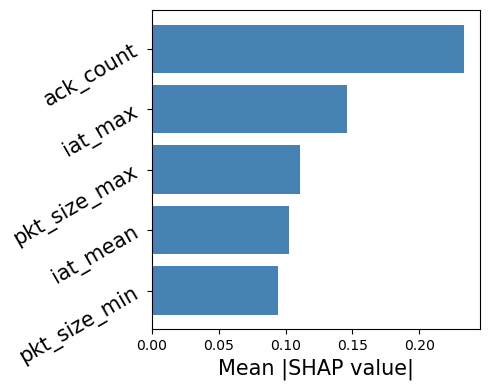

In [37]:
# --- Bar plot for top-K SHAP feature importance with custom size ---
TOP_K = 5
FIG_SIZE = (5, 4)   # width, height in inches

plt.figure(figsize=FIG_SIZE)
plt.barh(topk['feature'][::-1], topk['mean_abs_shap'][::-1], color='steelblue')

plt.xlabel("Mean |SHAP value|", fontsize=15)

plt.yticks(fontsize=15, rotation=30, ha='right')  # angled feature names

plt.tight_layout()
plt.savefig("feat_importance.pdf", dpi=300, bbox_inches="tight")
plt.show()


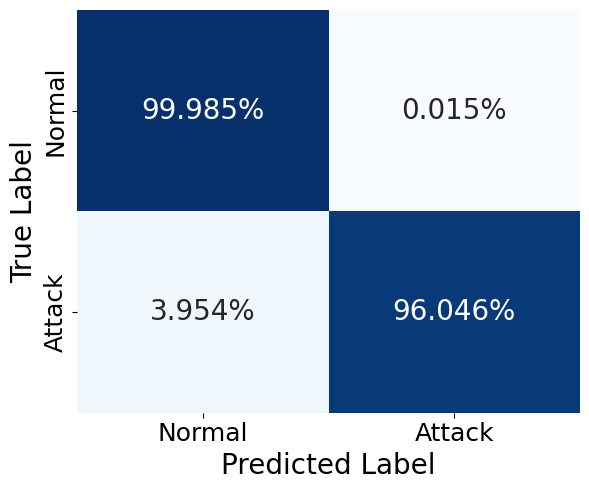

In [28]:
# Jupyter cell: plot normalized confusion matrix (percentages, 3 decimals)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# === Inputs ===
# y_test -> true labels
# y_pred -> predicted labels

# Compute confusion matrix and normalize (row-wise)
cm = confusion_matrix(y_test, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  # convert to %

# === Customize here ===
FIG_SIZE = (6, 5)
C_MAP = "Blues"
ANNOT_FONT_SIZE = 20
LABEL_FONT_SIZE = 20
TITLE = "Normalized Confusion Matrix - MLP (32-16)"
DECIMALS = 3  # change this for precision
TICK_FONT_SIZE = 18
# === Plot ===
plt.figure(figsize=FIG_SIZE)
sns.heatmap(
    cm_percent,
    annot=True,
    fmt=f".{DECIMALS}f",      # number of decimals displayed
    cmap=C_MAP,
    cbar=False,
    xticklabels=['Normal', 'Attack'],
    yticklabels=['Normal', 'Attack'],
    annot_kws={"size": ANNOT_FONT_SIZE}
)

plt.xlabel("Predicted Label", fontsize=LABEL_FONT_SIZE)
plt.ylabel("True Label", fontsize=LABEL_FONT_SIZE)
plt.xticks(fontsize=TICK_FONT_SIZE)
plt.yticks(fontsize=TICK_FONT_SIZE)
# Add percentage symbol manually
for t in plt.gca().texts:
    t.set_text(t.get_text() + "%")

plt.tight_layout()
plt.savefig("confusion_matrix_cyber.pdf", dpi=300)
plt.show()
